# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time


from sklearn.model_selection import train_test_split
from sklearn.model_selection import PredefinedSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


---
# Support functions

In [2]:
def plot_nan(df):
    """ Plot nan bar graph ordered by nan % in each feature"""        
    df_plot = pd.DataFrame({
        'Presenti': df.notna().sum(),
        'Mancanti (NaN)': df.isna().sum()
    })
    df_plot['pct_nan'] = (df_plot['Mancanti (NaN)'] / len(df)) * 100

    # Ordiniamo per % di NaN crescente (così nel grafico barh i più alti appaiono in cima)
    df_plot = df_plot.sort_values(by='pct_nan', ascending=True)

    # 2. Creazione del grafico a barre orizzontali
    ax = df_plot[['Presenti', 'Mancanti (NaN)']].plot(
        kind='barh',
        stacked=True,
        color=['#2ca02c', '#d62728'],
        figsize=(10, 30) # Altezza aumentata per leggere tutte le 145 feature
    )

    # 3. Formattazione
    plt.title('Distribuzione Valori Presenti vs NaN per Feature (Ordinato)', fontsize=16)
    plt.ylabel('Features', fontsize=14)
    plt.xlabel('Numero di righe', fontsize=12)

    # Label delle feature rimpicciolite
    plt.yticks(fontsize=7)

    plt.legend(loc='lower right', title='Stato')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('missing_values_horizontal_sorted.png')
    plt.show()

In [3]:
def plot_feature_distribution(df_feature, feature_name):
    """ Plot distribution of a given feature with percentages on top of bars """
    
    # 1. Calcolo frequenze e percentuali
    counts = df_feature.value_counts().sort_index()
    percentages = df_feature.value_counts(normalize=True).sort_index() * 100
    
    plt.figure(figsize=(8, 5))
    
    # Creazione del grafico (catturiamo l'oggetto 'ax' per aggiungere le etichette)
    ax = counts.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
    
    # 2. Aggiunta delle percentuali sopra le barre
    # Generiamo le etichette formattate (es. "15.4%")
    labels = [f'{p:.1f}%' for p in percentages]
    
    # bar_label aggiunge automaticamente il testo sopra ogni barra
    ax.bar_label(ax.containers[0], labels=labels, padding=3, fontsize=10, fontweight='bold')
    
    # 3. Formattazione estetica
    plt.title(f'Distribuzione della feature: {feature_name}', fontsize=14, fontweight='bold')
    plt.xlabel(feature_name, fontsize=12)
    plt.ylabel('Frequenza', fontsize=12)
    
    # Rotazione delle labels X se sono stringhe lunghe, altrimenti 0
    plt.xticks(rotation=45 if len(str(counts.index[0])) > 3 else 0)
    
    # Espandiamo il limite superiore dell'asse Y per far stare le scritte
    plt.ylim(0, counts.max() * 1.15)
    
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

In [4]:
def drop_high_nan_columns(df, threshold=0.95):
    min_valid_values = (1-threshold)*len(df)

    cols_to_drop = df.columns[df.notna().sum() < min_valid_values].tolist()
    
    if cols_to_drop:
        print(f"Colonne rimosse (> {threshold*100}% NaN):")
        print(cols_to_drop)
    else:
        print("Nessuna colonna rimossa.")

    return df.dropna(thresh=min_valid_values, axis=1)


In [5]:
def print_nan(df, types=None):
    """
    Esplora i NaN e i valori univoci (mostrando i valori effettivi) per ogni feature.
    """
    # Selezione colonne per tipo
    if types:
        selected_cols = df.select_dtypes(include=types).columns
    else:
        selected_cols = df.columns
        
    working_df = df[selected_cols]
    
    # Liste per raccogliere i dati
    data = []
    
    for col in selected_cols:
        # Calcolo metriche per la colonna
        nan_count = working_df[col].isna().sum()
        nan_perc = (nan_count / len(df)) * 100
        dtype = working_df[col].dtype
        
        # Otteniamo i valori unici (escludendo i NaN per chiarezza)
        uniques = working_df[col].dropna().unique()
        n_uniques = len(uniques)
        
        # Formattazione della stringa dei valori unici
        if n_uniques <= 10:
            uniques_str = str(list(uniques))
        else:
            # Se sono troppi, mostriamo un'anteprima
            uniques_str = f"{list(uniques[:5])}... (+{n_uniques-5} more)"
            
        data.append({
            'Feature': col,
            'Type': dtype,
            'Nan': nan_count,
            'Percentuale NaN (%)': f"{nan_perc:.2f}%",
            'Uniques Count': n_uniques,
            'Unique Values': uniques_str
        })

    # Creazione e ordinamento della tabella
    nan_table = pd.DataFrame(data).sort_values(by='Uniques Count')

    # Stampa con formattazione migliorata
    print(nan_table.to_string(index=False))
    return

# Esempio di chiamata:
# print_nan_and_uniques(df)

# Global Variables

In [6]:
seed = 42

FILENAME = "../data/train.csv"

# features = []

# Load the dataset

In [7]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

rows = df.shape[0]
cols = df.shape[1]
print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")

# Righe: 148301 # Colonne: 145



# Preprocessing

## 1. Remove duplicates

In [8]:
# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
feature_list = df.columns.to_list()
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df2 = df.T.drop_duplicates().T


# Rimuovi righe duplicate
df.drop_duplicates(inplace=True)


Ci sono colonne con lo stesso nome? False


## 2. Label extraction

In [9]:
X = df.drop(columns=["grade"])
y = df["grade"]

In [10]:
print(X['hardship_type_label'].unique())
print(X['hardship_loan_status_label'].unique())
print(X['hardship_status_label'].unique())

[nan 'interest only-3 months deferral']
[nan 'current' 'late (16-30 days)' 'in grace period' 'late (31-120 days)'
 'issued']
[nan 'completed' 'broken' 'active']


## 3. Data visualization

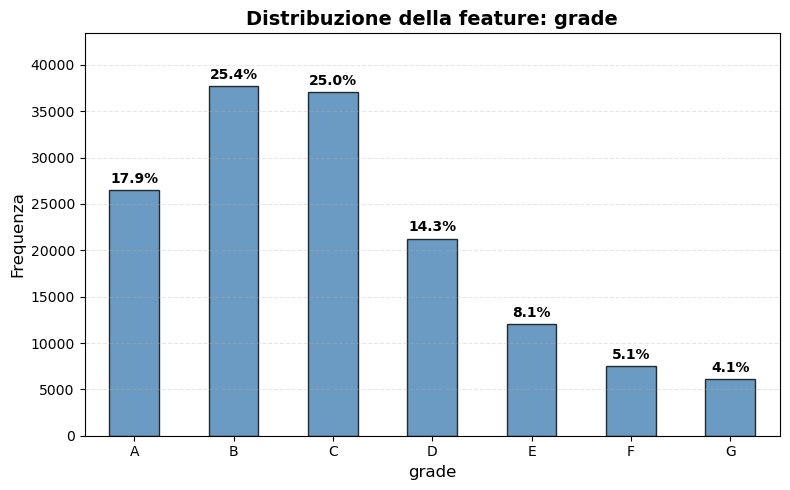

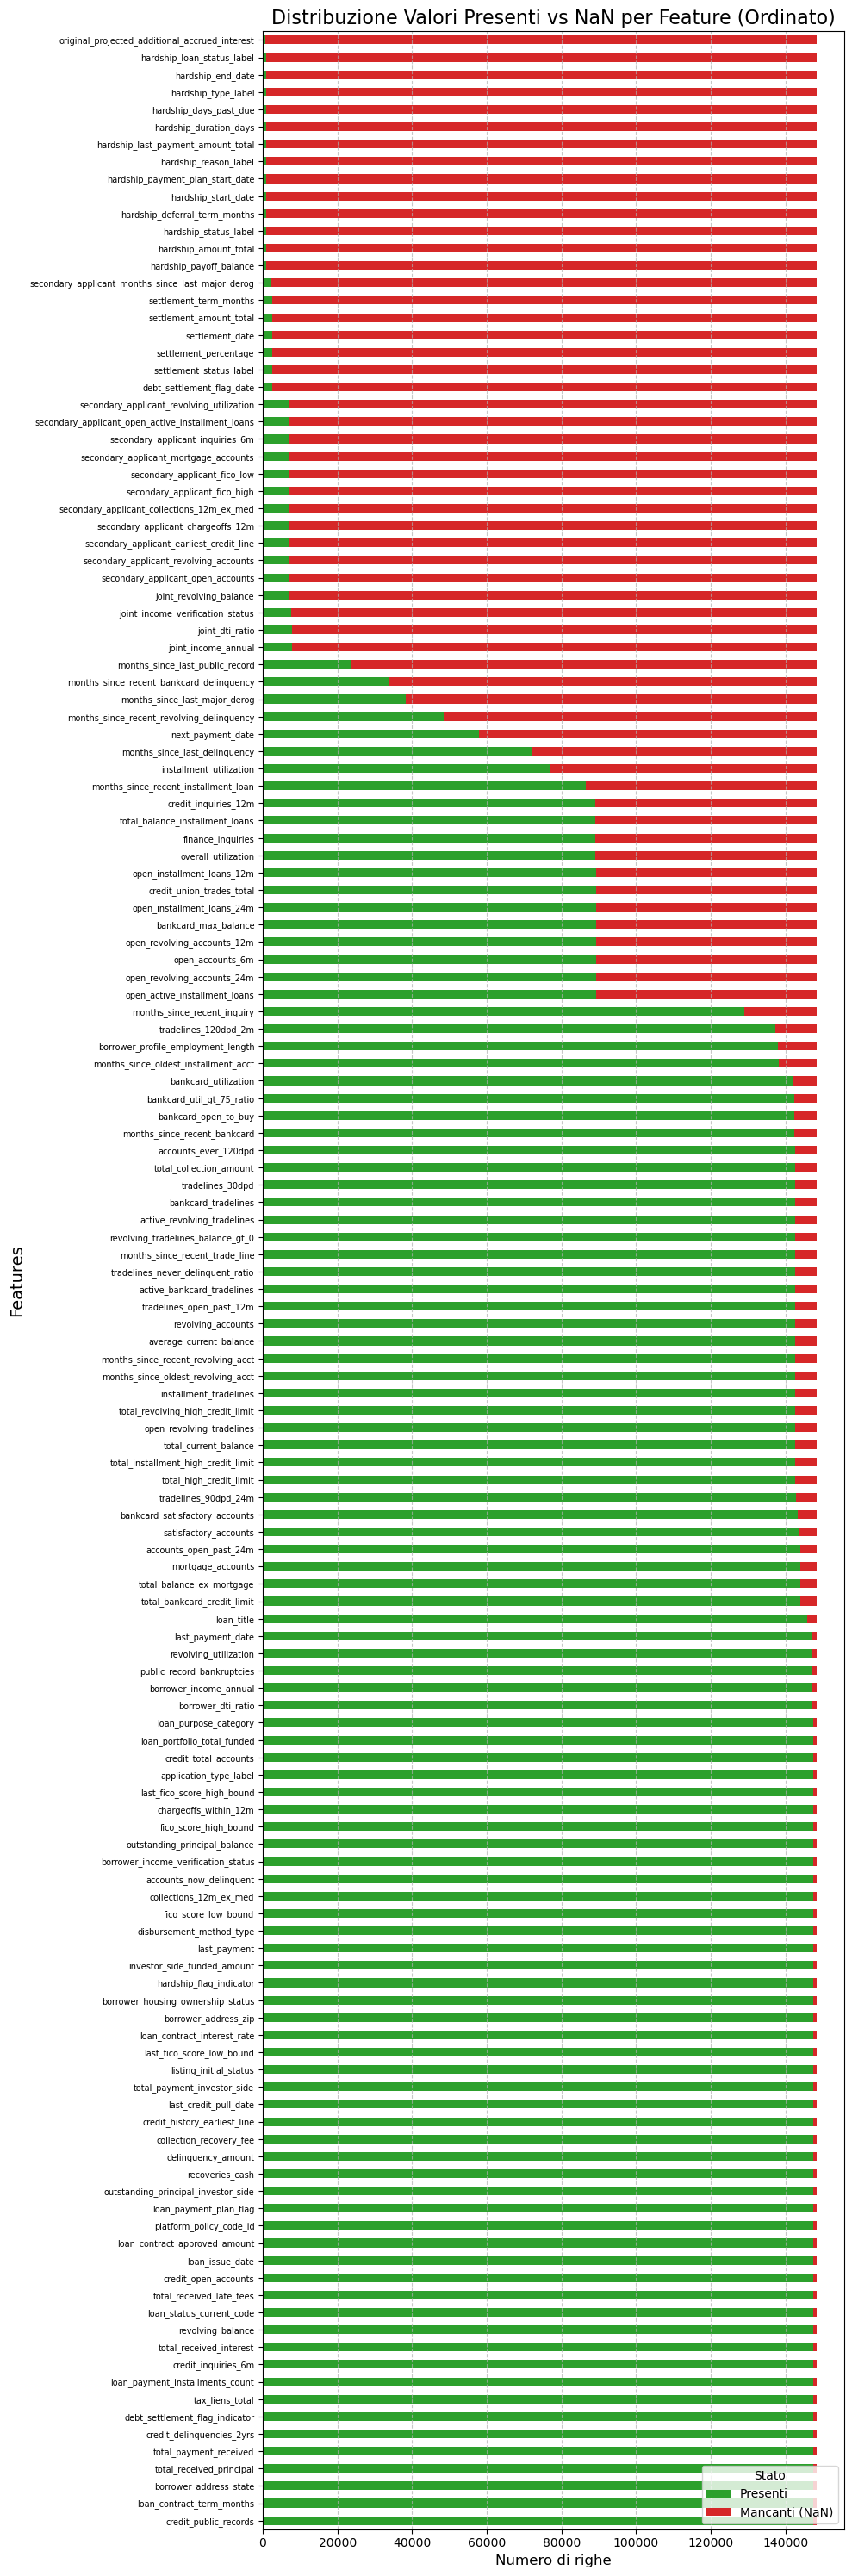

In [11]:
plot_feature_distribution(y, "grade")
plot_nan(X)

## 4. Features manipulation

In [12]:
for i in X.dtypes.unique():
    print("Type", i)

Type float64
Type object


In [13]:
# Teniamo una flag per indicare se un hardship loan e' stato concesso o meno
# X['has_hardship_plan'] = X['hardship_start_date'].notna().astype(float)

In [14]:
X = drop_high_nan_columns(X)

Colonne rimosse (> 95.0% NaN):
['joint_revolving_balance', 'secondary_applicant_fico_low', 'secondary_applicant_fico_high', 'secondary_applicant_earliest_credit_line', 'secondary_applicant_inquiries_6m', 'secondary_applicant_mortgage_accounts', 'secondary_applicant_open_accounts', 'secondary_applicant_revolving_utilization', 'secondary_applicant_open_active_installment_loans', 'secondary_applicant_revolving_accounts', 'secondary_applicant_chargeoffs_12m', 'secondary_applicant_collections_12m_ex_med', 'secondary_applicant_months_since_last_major_derog', 'hardship_type_label', 'hardship_reason_label', 'hardship_status_label', 'hardship_deferral_term_months', 'hardship_amount_total', 'hardship_start_date', 'hardship_end_date', 'hardship_payment_plan_start_date', 'hardship_duration_days', 'hardship_days_past_due', 'hardship_loan_status_label', 'original_projected_additional_accrued_interest', 'hardship_payoff_balance', 'hardship_last_payment_amount_total', 'debt_settlement_flag_date', 'set

### Categorical features

In [15]:
##### FEATURES EXTRACTION ######
# Trasforma "36 months" e "60 months" in float type
print("\n", X['loan_contract_term_months'].unique())
X['loan_contract_term_months'] = X['loan_contract_term_months'].str.extract(r'(\d+)').astype(float)

# Strip della stringa "years"
# Trasforma anni in float: < 1 diventa 0, 10+ diventa 10 
print("\n", X['loan_contract_term_months'].unique())
X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].str.replace(r'\+? years?', '', regex=True)
X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].replace({ '< 1': 0}).astype(float)


##### DROP FEATURES #####
categorical_to_drop = [
  'loan_title',                         # non significant column, grande sparsita' di dati. Sufficiente loan_purpose_category come aggregazione di scopo del prestito
  'borrower_address_zip',               # non significant column, esiste una colonna per identificazione stati
]

X = X.drop(columns=categorical_to_drop)


 [' 36 months' ' 60 months' nan]

 [36. 60. nan]


### Numerical features

In [16]:
# 1. DROP: Data Leakage (Future Information)
numerical_to_drop = [
    # Future income for loaner
    'total_payment_received', 'total_received_principal', 'recoveries_cash',
    'collection_recovery_fee', 'last_payment', 'outstanding_principal_balance',
    'total_received_interest', 'total_received_late_fees',
]

X = X.drop(columns=numerical_to_drop)


print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

Nuovo # Colonne: 101



In [17]:
# 2. DROP: Secondary/Joint Applicant info
# application_type_label ci informa gia' se il tipo di prestito e' individual o

joint_and_secondary_cols = [col for col in X.columns if col.startswith('joint_') or col.startswith('secondary_')]

# DROP: tutti i campi relativi a settlement sono data leakage
settlement_cols = [col for col in X.columns if 'settlement' in col]

to_drop = joint_and_secondary_cols + settlement_cols

X = X.drop(columns=to_drop)

print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

Nuovo # Colonne: 97



In [18]:
# Feature categoriche in cui i valori NaN sono riempiti con una nuova label Unknown
categorical_to_unknown = [
  'borrower_address_state',
  'loan_purpose_category',
  'loan_status_current_code',
  'borrower_income_verification_status',
  'borrower_housing_ownership_status'
]

# 2. Fill with 'unknown'
for col in categorical_to_unknown:
    X[col] = X[col].fillna('unknown')


# 3. KEEP & FILL: "Months Since" columns (NaN = Never happened)
# We fill with a large number (e.g., 100 months) to signify "very long time ago / never"
structural_cols = [
    'months_since_last_public_record',
    'months_since_recent_bankcard_delinquency',
    'months_since_last_major_derog',
    'months_since_recent_revolving_delinquency',
    'months_since_last_delinquency'
]

for col in structural_cols:
    X[col] = X[col].fillna(100)


In [19]:
##### DATES #####
X['loan_issue_date'] = pd.to_datetime(X['loan_issue_date'], format='%b-%Y')

X['issue_month'] = X['loan_issue_date'].dt.month
X['issue_year'] = X['loan_issue_date'].dt.year

# cyclical Encoding
X['issue_month_sin'] = np.sin(2 * np.pi * X['issue_month'] / 12)
X['issue_month_cos'] = np.cos(2 * np.pi * X['issue_month'] / 12)

# calculate
X['credit_history_earliest_line'] = pd.to_datetime(X['credit_history_earliest_line'], format='%b-%Y')

# Numero mesi passati tra prima richiesta credito e loan date 
X['months_since_earliest_cr_line'] = (
    (X['loan_issue_date'].dt.year - X['credit_history_earliest_line'].dt.year) * 12 +
    (X['loan_issue_date'].dt.month - X['credit_history_earliest_line'].dt.month)
)


# Tutte le features rimanenti con date non sono rilevanti (leakage)
date_cols = [col for col in X.columns if 'date' in col]
to_drop = [
    'credit_history_earliest_line',     # used for feature extraction
    'issue_month',                      # used for feature extraction: sin/cos encoding
    ] + date_cols


X = X.drop(columns=to_drop)
print(f"Columns remaining: {X.shape[1]}")

Columns remaining: 96


## NaN management

In [20]:
print_nan(X)

                                  Feature    Type   Nan Percentuale NaN (%)  Uniques Count                                                                                                                                                                                                                             Unique Values
                loan_contract_term_months float64   890               0.60%              2                                                                                                                                                                                                      [np.float64(36.0), np.float64(60.0)]
                   loan_payment_plan_flag  object   949               0.64%              2                                                                                                                                                                                                                                ['n', 'y']
                   listin

In [21]:
# Split train test: 0.25
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)

In [22]:
# Feature categoriche in cui i valori NaN possono essere riempiti con la moda:
# valori con 2 etichette, in cui la mancanza di un dato viene trattato come "no" o come occorrenza piu' frequente
fill_to_mode =[
  # Categorical
  'disbursement_method_type',
  'application_type_label',
  'listing_initial_status',
  'loan_payment_plan_flag',
  'hardship_flag_indicator',      # n/y
  'loan_payment_plan_flag',       # n/y

  # Numerical 
  'loan_contract_term_months'  # 36/60 mesi
]

for i in fill_to_mode:
    print(X[i].unique())


# 1. Setup the imputer with 'most_frequent' (Mode)
mode_imputer = SimpleImputer(strategy='most_frequent')

# 2. Fit on TRAIN only (Learn the most common categories)
# It's important to select only these columns to avoid errors with other types
mode_imputer.fit(X_train[fill_to_mode])

# 3. Transform BOTH (Fill NaNs)
# We assign the result back to the specific columns to keep the DataFrame structure
X_train[fill_to_mode] = mode_imputer.transform(X_train[fill_to_mode])
X_val[fill_to_mode] = mode_imputer.transform(X_val[fill_to_mode])





['cash' 'directpay' nan]
['individual' 'joint app' nan]
['f' 'w' nan]
['n' nan 'y']
['n' nan 'y']
['n' nan 'y']
[36. 60. nan]


In [23]:

""" numerical_to_mean = [
    'borrower_dti_ratio',
    'borrower_income_annual',
    'revolving_utilization',
    'total_revolving_high_credit_limit',
] """

numerical_to_mean = X_train.select_dtypes(include=['float', 'int']).columns

# Setup the imputer
imputer = SimpleImputer(strategy='mean')

# Fit on TRAIN only (Learn the medians)
imputer.fit(X_train[numerical_to_mean])

# Transform BOTH (Fill NaNs)
X_train[numerical_to_mean] = imputer.transform(X_train[numerical_to_mean])
X_val[numerical_to_mean] = imputer.transform(X_val[numerical_to_mean])

In [24]:
print(X_train['hardship_flag_indicator'].unique())

['n' 'y']


                                  Feature    Type  Nan Percentuale NaN (%)  Uniques Count                                                                                                                                                                                                                             Unique Values
                loan_contract_term_months  object    0               0.00%              2                                                                                                                                                                                                                              [36.0, 60.0]
                   loan_payment_plan_flag  object    0               0.00%              2                                                                                                                                                                                                                                ['n', 'y']
                   listing_i

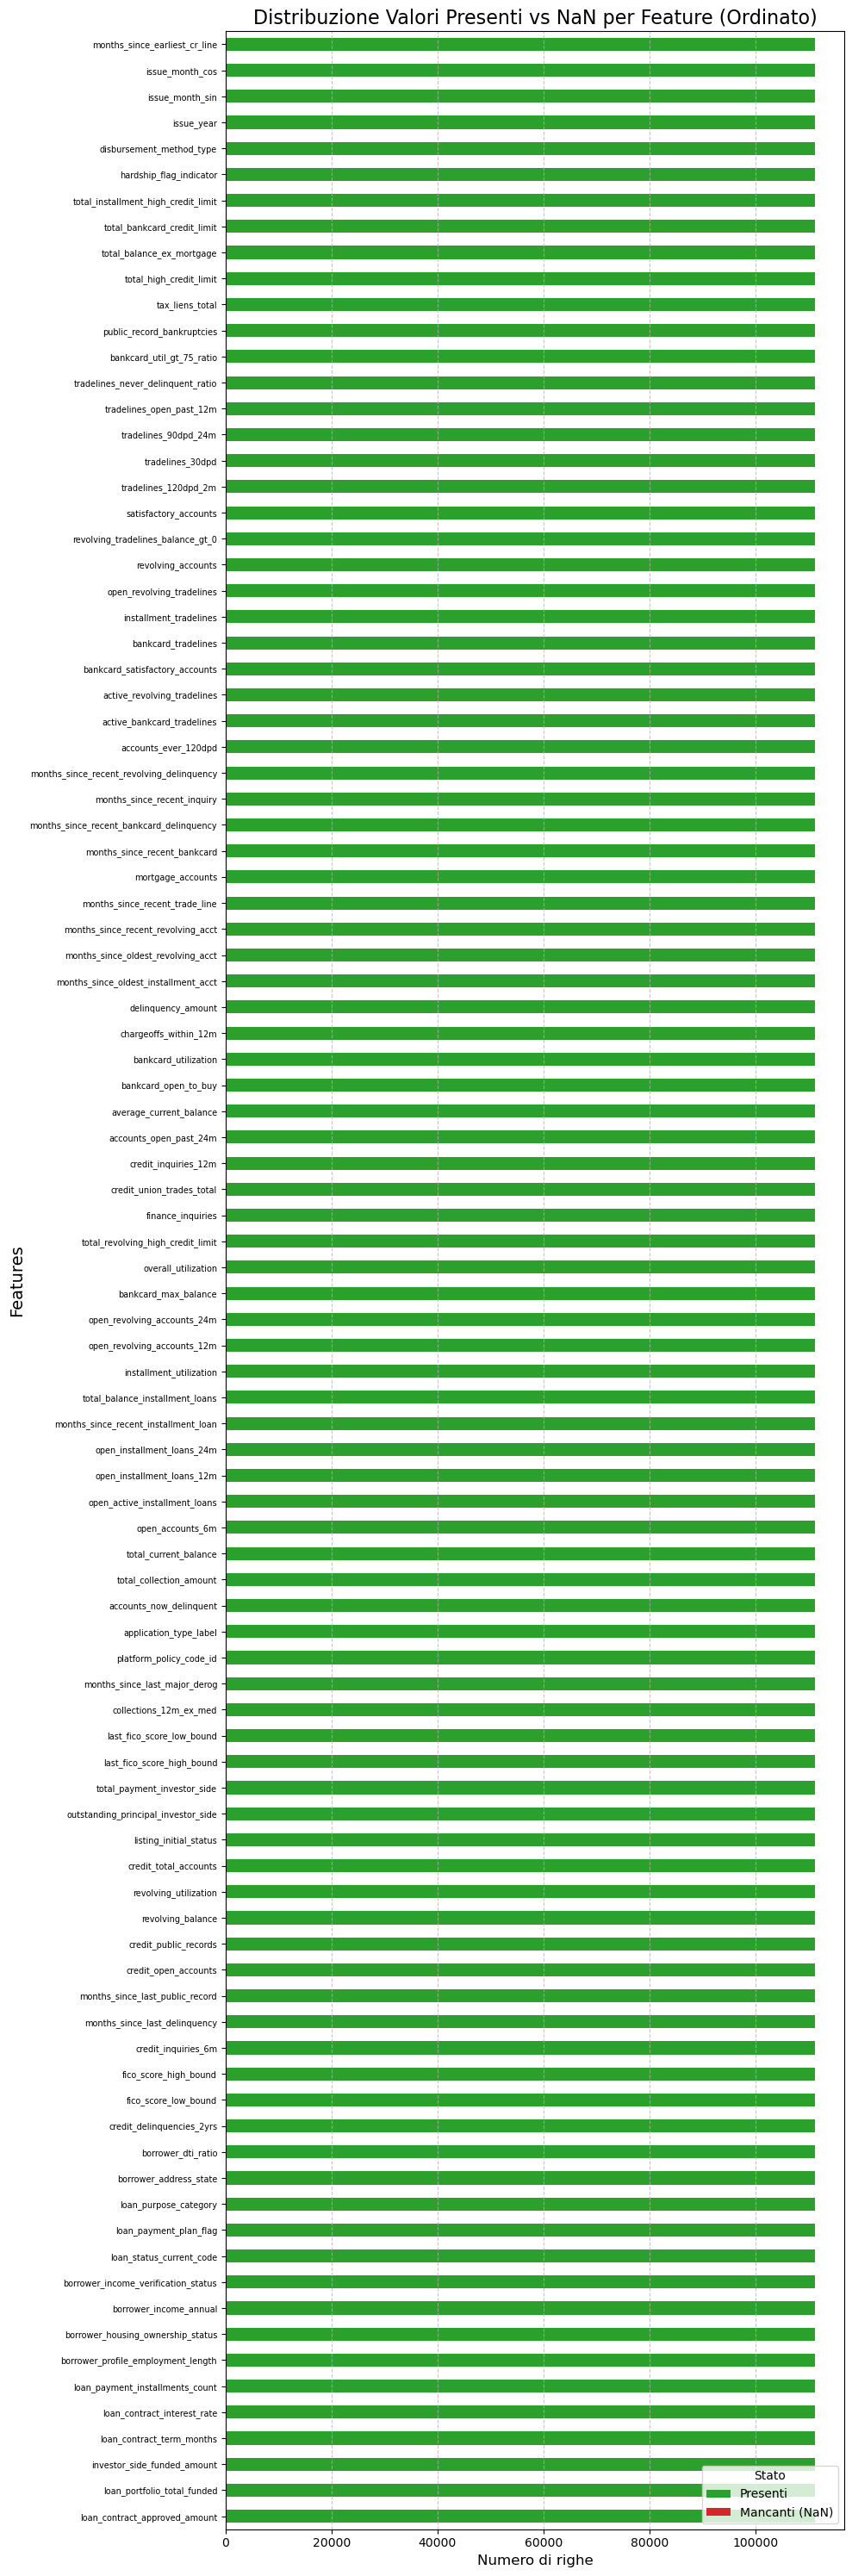

                                  Feature    Type  Nan Percentuale NaN (%)  Uniques Count                                                                                                                                                                                                                  Unique Values
                loan_contract_term_months  object    0               0.00%              2                                                                                                                                                                                                                   [36.0, 60.0]
                   loan_payment_plan_flag  object    0               0.00%              2                                                                                                                                                                                                                     ['n', 'y']
                   listing_initial_status  object    0       

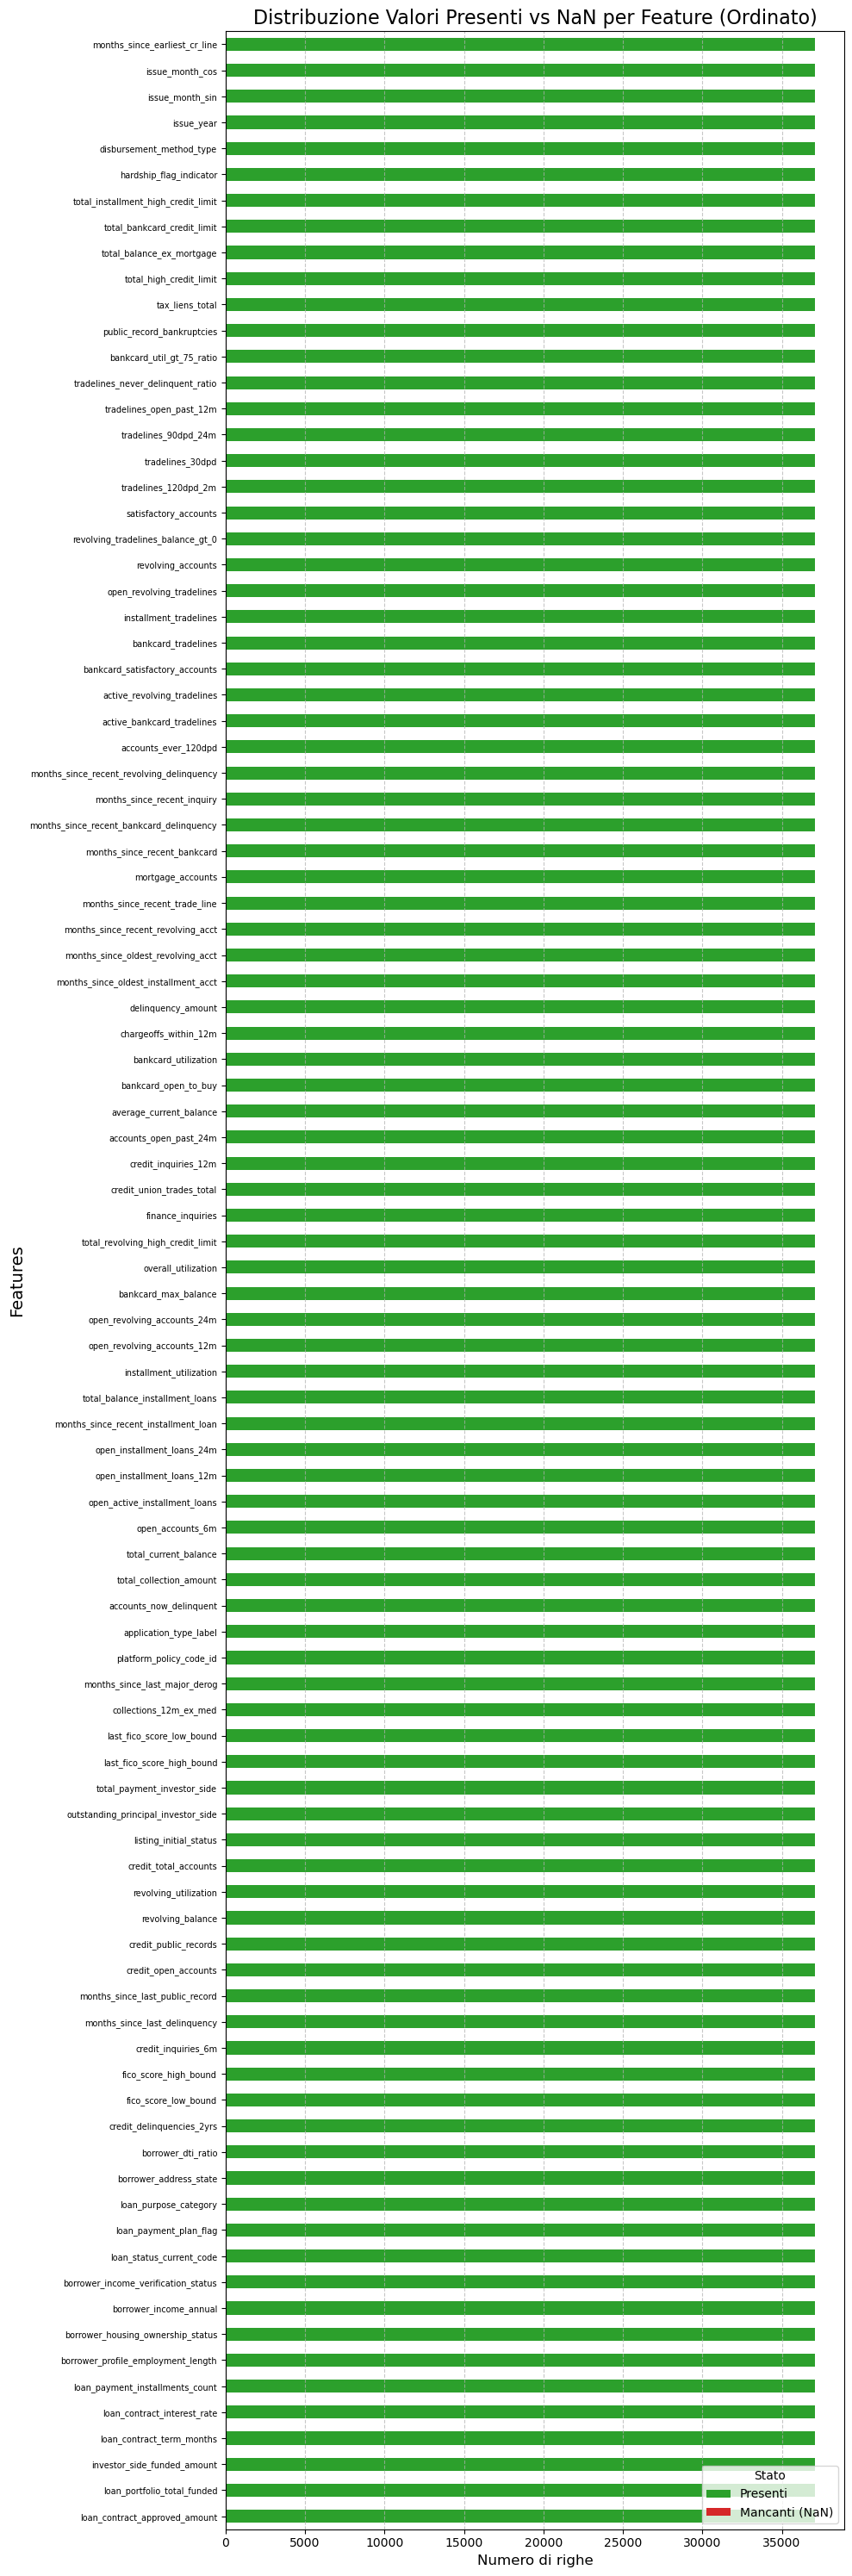

In [25]:
print_nan(X_train)
plot_nan(X_train)

print_nan(X_val)
plot_nan(X_val)

In [26]:
""" import re

# Regex per identificare il pattern mmm-yyyy
date_regex = re.compile(r'^[a-z]{3}-\d{4}$', re.IGNORECASE)

# Identificazione colonne temporali
date_cols = [
    col for col in df.columns
    if not df[col].dropna().empty and
    df[col].dropna().head(10).apply(lambda x: bool(date_regex.match(str(x)))).all()
]

# Estrazione statistiche e distribuzione label per righe non-NaN
stats = []
grade_order = sorted(df['grade'].unique())

for col in date_cols:
    non_nan_df = df[df[col].notna()]
    total_non_nan = len(non_nan_df)

    # Conteggio grade per le righe dove la data è presente
    grade_counts = non_nan_df['grade'].value_counts().to_dict()

    entry = {
        'Feature': col,
        'Nan': df[col].isna().sum(),
        'Nan %': (df[col].isna().sum() / len(df)) * 100,
        'Righe Non-NaN': total_non_nan
    }

    # Aggiungiamo i conteggi per ogni grado (A, B, C...)
    for g in grade_order:
        entry[f'Grade {g}'] = grade_counts.get(g, 0)

    stats.append(entry)

# Creazione DataFrame finale
summary_df = pd.DataFrame(stats).sort_values(by='Nan %', ascending=False)
print(summary_df.to_string(index=False)) """

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_18981/2303446274.py:4: SyntaxWarning: invalid escape sequence '\d'
  date_regex = re.compile(r'^[a-z]{3}-\d{4}$', re.IGNORECASE)


" import re\n\n# Regex per identificare il pattern mmm-yyyy\ndate_regex = re.compile(r'^[a-z]{3}-\\d{4}$', re.IGNORECASE)\n\n# Identificazione colonne temporali\ndate_cols = [\n    col for col in df.columns\n    if not df[col].dropna().empty and\n    df[col].dropna().head(10).apply(lambda x: bool(date_regex.match(str(x)))).all()\n]\n\n# Estrazione statistiche e distribuzione label per righe non-NaN\nstats = []\ngrade_order = sorted(df['grade'].unique())\n\nfor col in date_cols:\n    non_nan_df = df[df[col].notna()]\n    total_non_nan = len(non_nan_df)\n\n    # Conteggio grade per le righe dove la data è presente\n    grade_counts = non_nan_df['grade'].value_counts().to_dict()\n\n    entry = {\n        'Feature': col,\n        'Nan': df[col].isna().sum(),\n        'Nan %': (df[col].isna().sum() / len(df)) * 100,\n        'Righe Non-NaN': total_non_nan\n    }\n\n    # Aggiungiamo i conteggi per ogni grado (A, B, C...)\n    for g in grade_order:\n        entry[f'Grade {g}'] = grade_counts

In [ ]:
numerical_cols = X.select_dtypes(include=['float', 'int']).columns
#categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# 2. Loop and Plot
for col in numerical_cols:
    plt.figure(figsize=(10, 4))

    if col in numerical_cols:
        # --- NUMERICAL: SCATTER PLOT ---
        # Plot Index vs Value. Outliers will appear vertically distant from the main cloud.
        plt.scatter(x=X.index, y=X[col], alpha=0.5)

        # Optional: Add lines for Mean +/- 3 Std Dev to help identify extreme values
        mean = X[col].mean()
        std = X[col].std()
        plt.axhline(mean + 3*std, color='r', linestyle='--', label='Mean + 3SD')
        plt.axhline(mean - 3*std, color='r', linestyle='--', label='Mean - 3SD')
        plt.legend()
        plt.title(f"Numerical Outliers: {col}")
        plt.ylabel("Value")
        plt.xlabel("Index (Row Number)")

    else:
        # --- CATEGORICAL: BAR CHART ---
        # Outliers here are 'Rare Categories'. We plot frequency.
        # If a bar is extremely short (e.g., count=1), it's a rare category.
        X_train[col].value_counts().plot(kind='bar', color='orange')
        plt.title(f"Categorical Frequencies: {col}")
        plt.ylabel("Count")
        plt.xlabel("Category")

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    #plt.show()


/tmp/ipykernel_18981/1129989892.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


In [ ]:
def analyze_and_plot_outliers(df):
    # 1. Select only numerical columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if len(numeric_cols) == 0:
        print("No numerical columns found!")
        return

    # 2. Prepare the figure
    # Create one subplot per column
    fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 4 * len(numeric_cols)))

    # Handle case if there's only one numerical column (axes is not a list)
    if len(numeric_cols) == 1:
        axes = [axes]

    print(f"{'Column':<20} | {'Lower Cutoff':<15} | {'Upper Cutoff':<15}")
    print("-" * 55)

    for i, col in enumerate(numeric_cols):
        ax = axes[i]

        # 3. Calculate IQR stats
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        print(f"{col:<20} | {lower_bound:<15.2f} | {upper_bound:<15.2f}")

        # 4. Plot Boxplot
        # vert=False makes it horizontal, which is often easier to read
        ax.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red', linewidth=2))

        # 5. Add Cutoff Lines
        ax.axvline(lower_bound, color='orange', linestyle='--', linewidth=1.5, label='Lower Limit')
        ax.axvline(upper_bound, color='orange', linestyle='--', linewidth=1.5, label='Upper Limit')

        ax.set_title(f"Distribution & Cutoffs: {col}")
        ax.set_xlabel("Value")
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Run it on your training data
analyze_and_plot_outliers(X)

In [ ]:

def calculate_outlier_percentage(df):
    # Select numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # Create a list to store results
    results = []

    for col in numeric_cols:
        # 1. Calculate IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 2. Count Outliers
        # An outlier is anything strictly less than lower OR strictly greater than upper
        n_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

        # 3. Calculate Percentage
        total_rows = df.shape[0]
        percentage = (n_outliers / total_rows) * 100

        results.append({
            "Column": col,
            "Lower Cutoff": round(lower_bound, 2),
            "Upper Cutoff": round(upper_bound, 2),
            "Outliers Count": n_outliers,
            "Outliers %": round(percentage, 2)
        })

    # Convert to DataFrame for a nice table display
    results_df = pd.DataFrame(results)

    # Sort by percentage descending to see the "worst" columns first
    results_df = results_df.sort_values(by="Outliers %", ascending=False)

    return results_df

# Run and display
outlier_stats = calculate_outlier_percentage(X)
with pd.option_context('display.max_rows', None):
    print(outlier_stats)

In [ ]:
"""
# 1. Selezione delle sole colonne numeriche
# (Assicurati di aver già rimosso o trasformato le date e le categoriche)
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_val_numeric = X_val.select_dtypes(include=[np.number])

# 2. Imputazione dei valori mancanti (la PCA non ammette NaN)
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train_numeric)
X_val_imputed = imputer.transform(X_val_numeric)

# 3. Standardizzazione (Fondamentale per la PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

# 4. Applicazione PCA
# Usiamo n_components=0.95 per mantenere il 95% della varianza totale
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"Dimensioni originali: {X_train_scaled.shape[1]}")
print(f"Dimensioni dopo PCA (90% varianza): {X_train_pca.shape[1]}")

# --- Visualizzazione della Varianza Spiegata ---
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Numero di Componenti')
plt.ylabel('Varianza Spiegata Cumulativa')
plt.title('Analisi della Varianza per PCA')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.grid()
plt.show() """

In [ ]:
""" # 1. Recupera i nomi delle colonne originali usate per la PCA
# (Assumendo che X_train_scaled sia il risultato dello StandardScaler)
feature_names = X_train.select_dtypes(include=[np.number]).columns

# 2. Crea un DataFrame con l'importanza relativa (Varianza Spiegata)
pca_importance = pd.DataFrame({
    'Componente': [f'PCA_{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Varianza Spiegata': pca.explained_variance_ratio_,
    'Varianza Cumulativa': np.cumsum(pca.explained_variance_ratio_)
})

print("--- Importanza Relativa dei Componenti PCA ---")
print(pca_importance.to_string(index=False))

# 3. Analisi dei "Loadings" (quali feature pesano di più sui componenti)
# Prendiamo ad esempio il primo componente (PCA_1)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PCA_{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    index=feature_names
)

print("\n--- Top 5 Feature originali per importanza in PCA_1 ---")
# Usiamo il valore assoluto perché un peso molto negativo è importante quanto uno positivo
top_features_pca1 = loadings['PCA_2'].abs().sort_values(ascending=False)
print(top_features_pca1) """

## Features encoding

In [ ]:

categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Create encoder with handle_unknown to deal with unseen categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on training data only
ohe.fit(X_train[categorical_features])

# Transform both sets
X_train_encoded = ohe.transform(X_train[categorical_features])
X_val_encoded = ohe.transform(X_val[categorical_features])

# Get feature names for the encoded columns
encoded_feature_names = ohe.get_feature_names_out(categorical_features)

# Create DataFrames with the encoded features
X_train_ohe = pd.DataFrame(X_train_encoded,
                           columns=encoded_feature_names,
                           index=X_train.index)
X_val_ohe = pd.DataFrame(X_val_encoded,
                         columns=encoded_feature_names,
                         index=X_val.index)

# Drop original categorical columns and concatenate encoded ones
X_train = X_train.drop(columns=categorical_features).join(X_train_ohe)
X_val = X_val.drop(columns=categorical_features).join(X_val_ohe)


le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.fit(y_val)


print(X_train.shape[1])
print(X_train.head())

### PCA

In [ ]:
""" 

# 1. Trasforma X_train_pca in DataFrame
# Usiamo l'indice di X_train_ohe per garantire l'allineamento perfetto delle righe
X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=[f'PCA_{i+1}' for i in range(X_train_pca.shape[1])],
    index=X_train_ohe.index
)

# 2. Unione (Concatenazione orizzontale) per il Training Set
X_train_final = pd.concat([X_train_ohe, X_train_pca_df], axis=1)

# 3. Trasforma X_val_pca in DataFrame
X_val_pca_df = pd.DataFrame(
    X_val_pca,
    columns=[f'PCA_{i+1}' for i in range(X_val_pca.shape[1])],
    index=X_val_ohe.index
)

# 4. Unione per il Validation Set
X_val_final = pd.concat([X_val_ohe, X_val_pca_df], axis=1)

print(f"Nuova dimensione Training Set: {X_train_final.shape}")
print(f"Nuova dimensione Validation Set: {X_val_final.shape}") """

In [ ]:
""" ## TODO: quale encoder e' meglio usare?
# ricerca: categorical feature transform in ml
# https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/

for col in X_train[categorical_features].columns:
    le = LabelEncoding(sparse_output=False)
    values_train = X_train[col].dropna().values
    values_val = X_val[col].dropna().values

    values = np.union1d(values_train, values_val)

    le = le.fit(values)
    X_train[col] = le.transform(X_train[col])
    X_val[col] = le.transform(X_val[col])

print(X_train.head())


# y encoding
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.fit(y_val) """

# TODO
- VERIFICA OUTLIER E RIPARAZIONE
- FILL MISSING VALUES
- DATA BALANCING (Undersampling to 20 k?)
- SCALING
- PCA ??

## Define the scalers to be used

In [ ]:
# Scalers to test
scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler()
}

## Apply Random Forests with hyperparameters tuning

In [ ]:
param_grid_rf = {
    'clf__n_estimators': [10, 100, 1000],
    'clf__max_features': [None, 'sqrt', 'log2'],
    'clf__criterion': ['gini', 'entropy', 'log_loss'],
    'clf__max_depth': [None, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}

# Grid Search with Pipeline
best_score = 0

for scaler_name, scaler in scalers.items():

        pipeline = Pipeline([
            #("scaler", scaler),
            ("clf", RandomForestClassifier(random_state=seed))
        ])

        # Perform Grid Search

        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            file = open("rf_scaler.save","wb")def plot_nan(df):
    """ Plot nan bar graph ordered by nan % in each feature"""
    df_plot = pd.DataFrame({
        'Presenti': df.notna().sum(),
        'Mancanti (NaN)': df.isna().sum()
    })
    df_plot['pct_nan'] = (df_plot['Mancanti (NaN)'] / len(df)) * 100

    # Ordiniamo per % di NaN crescente (così nel grafico barh i più alti appaiono in cima)
    df_plot = df_plot.sort_values(by='pct_nan', ascending=True)

    # 2. Creazione del grafico a barre orizzontali
    ax = df_plot[['Presenti', 'Mancanti (NaN)']].plot(
        kind='barh',
        stacked=True,
        color=['#2ca02c', '#d62728'],
        figsize=(10, 30) # Altezza aumentata per leggere tutte le 145 feature
    )

    # 3. Formattazione
    plt.title('Distribuzione Valori Presenti vs NaN per Feature (Ordinato)', fontsize=16)
    plt.ylabel('Features', fontsize=12)
    plt.xlabel('Numero di righe', fontsize=12)

    # Label delle feature rimpicciolite
    plt.yticks(fontsize=7)

    plt.legend(loc='lower right', title='Stato')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('missing_values_horizontal_sorted.png')
    plt.show()
            pickle.dump(grid.best_estimator_['scaler'], file)
            file.close()
            file = open("rf.save","wb")
            pickle.dump(grid.best_estimator_['clf'], file)
            file.close()

## Apply Logistic Regression

In [ ]:
# train/val split
indices = np.arange(X.shape[0])
train_idx, val_idx = train_test_split(indices, test_size=0.1, stratify=y, random_state=seed)

X_val_raw = X[val_idx,:]
y_val = y[val_idx]
X_train_raw = X[train_idx,:]
y_train = y[train_idx]


best_score = 0
for name, scaler in scalers.items():
    # scale data


    # train model

    print("Performance:",score)

    if score > best_score:
        best_score = score
        file_scaler = open("lr_scaler.save","wb")
        pickle.dump(scaler, file_scaler)
        file_clf = open("lr.save","wb")
        pickle.dump(clf, file_clf)
        file_clf.close()



## Apply Support Vector Classifier with hyperparameters tuning

In [ ]:
# SVC param grid
param_grid_svc = {'clf__C': [0.1, 1, 10, 100, 1000],
              'clf__kernel': ["linear", "poly", "rbf"]}

# Grid Search with Pipeline
best_score = 0
for scaler_name, scaler in scalers.items():

        pipeline = Pipeline([
            ("scaler", scaler),
            ("clf", SVC(random_state=seed))
        ])

        # Perform Grid Search


        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            file = open("svc_scaler.save","wb")
            pickle.dump(grid.best_estimator_['scaler'], file)
            file.close()
            file = open("svc.save","wb")
            pickle.dump(grid.best_estimator_['clf'], file)
            file.close()
